# Plate-aware train/validation/test split design

This notebook defines and documents the train/validation/test split for the T-ChIC gastruloid dataset.

## Objectives

- Treat H3K4me3 and H3K27me3 as separate prediction tasks.
- Keep all cells from the same experimental plate in one partition.
- Target a 70/15/15 train/validation/test split.
- Represent every developmental day in every partition.
- Balance experimental replicates and technical batches where possible.
- verify that no plate-level leakage occurs.
- Exportation of the selected plate assignments for downstream benchmark preparation

This notebook defines the plate assignments. Downstream preparation notebooks can load the exportation of it and align the corresponding raw-count data to the same retained cells.

## 1. Environment

In [1]:
import sys
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python executable:", sys.executable)
print("anndata:", ad.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)

Python executable: /home/michiel/miniforge3/envs/thesis/bin/python
anndata: 0.11.4
numpy: 2.2.6
pandas: 2.3.3


## 2. Load cell metadata

The source H5AD is opened in backed, read-only mode. Only the observation metadata (`obs`) are copied into memory. The count matrices are not loaded because they are not needed to design the split.


In [2]:
from pathlib import Path

DATA_PATH = Path(
    "/home/vivek/NOBINFBACKUP/projects/mGast_tchic/"
    "adata_files/allsamples_genelevel_RNAandChIC_counts.filt-norm.h5ad"
)

if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

adata = ad.read_h5ad(DATA_PATH, backed="r")

try:
    dataset_shape = adata.shape
    obs = adata.obs.copy()
finally:
    adata.file.close()

print("Dataset:", DATA_PATH)
print("Dataset shape:", dataset_shape)
print("Metadata shape:", obs.shape)
print("Source file closed after reading metadata.")

Dataset: /home/vivek/NOBINFBACKUP/projects/mGast_tchic/adata_files/allsamples_genelevel_RNAandChIC_counts.filt-norm.h5ad
Dataset shape: (37265, 24877)
Metadata shape: (37265, 17)
Source file closed after reading metadata.


### Initial metadata check

The following checks confirm the number of cells, available metadata columns, histone marks, developmental days and named plate samples.

In [3]:
print("Number of cells:", len(obs))
print("Number of metadata columns:", obs.shape[1])
print("Number of samples/plates:", obs["sample"].nunique())
print()

print("Histone marks:")
print(obs["mark"].value_counts().sort_index())
print()

print("Developmental days:")
print(obs["day"].value_counts().sort_index())
print()

print("Metadata columns:")
print(obs.columns.tolist())

Number of cells: 37265
Number of metadata columns: 17
Number of samples/plates: 120

Histone marks:
mark
H3K4me3     17498
H3K27me3    19767
Name: count, dtype: int64

Developmental days:
day
0    3845
3    4104
4    7710
5    7106
6    7029
7    7471
Name: count, dtype: int64

Metadata columns:
['obs_names', 'sample', 'plate_batch', 'barcode_vasa', 'day', 'rep', 'mark', 'plate_grp', 'barcode_nla', 'seqrun', 'exp_batch', 'day_rep', 'batch_day_rep', 'sizefactors_deconv_spliced', 'sizefactors_deconv_unspliced', 'sizefactors_deconv_chic', 'sizefactors_deconv_total']


## 3. Define the experimental grouping unit

Individual cells are not fully independent observations because hundreds of cells were processed together on the same 384-well plate. Cells from the same plate can share technical characteristics caused by handling, reagents and processing conditions.

In this dataset:

- `sample` is the descriptive identifier of an individual plate;
- `plate_batch` is a numeric identifier for that same plate;
- `plate_grp` is the plate number within an experimental condition and is therefore not globally unique;
- `rep` identifies a higher-level experimental replicate that can contain multiple plates;
- `day` identifies the developmental time point;
- `mark` identifies the measured histone modification.

The split will assign complete `sample` plates to train, validation or test. Other variables will be used to evaluate and balance the resulting partitions.

In [4]:
plate_metadata_columns = [
    "plate_batch",
    "day",
    "rep",
    "mark",
    "plate_grp",
    "seqrun",
    "exp_batch",
    "day_rep",
    "batch_day_rep",
]

values_per_sample = (
    obs.groupby("sample", observed=True)[plate_metadata_columns]
    .nunique()
)

maximum_values_per_sample = values_per_sample.max()

display(
    maximum_values_per_sample.rename(
        "maximum number of values within one sample"
    ).to_frame()
)

assert (maximum_values_per_sample == 1).all(), (
    "At least one sample contains inconsistent plate-level metadata."
)

print("Check passed: all plate-level metadata are constant within each sample.")

,maximum number of values within one sample
plate_batch,1
day,1
rep,1
mark,1
plate_grp,1
seqrun,1
exp_batch,1
day_rep,1
batch_day_rep,1


Check passed: all plate-level metadata are constant within each sample.


In [5]:
plate_batches_per_sample = (
    obs.groupby("sample", observed=True)["plate_batch"]
    .nunique()
)

samples_per_plate_batch = (
    obs.groupby("plate_batch", observed=True)["sample"]
    .nunique()
)

print(
    "Maximum plate_batch values per sample:",
    plate_batches_per_sample.max(),
)
print(
    "Maximum sample values per plate_batch:",
    samples_per_plate_batch.max(),
)

assert plate_batches_per_sample.max() == 1
assert samples_per_plate_batch.max() == 1

print("Check passed: sample and plate_batch have a one-to-one relationship.")

Maximum plate_batch values per sample: 1
Maximum sample values per plate_batch: 1
Check passed: sample and plate_batch have a one-to-one relationship.


### Plate-level metadata table

The original `obs` table contains one row per cell. For split design, it is converted into a table containing one row per experimental plate and the number of retained cells on that plate.

In [6]:
plate_table = (
    obs.groupby("sample", observed=True)
    .agg(
        n_cells=("sample", "size"),
        plate_batch=("plate_batch", "first"),
        day=("day", "first"),
        rep=("rep", "first"),
        mark=("mark", "first"),
        plate_grp=("plate_grp", "first"),
        seqrun=("seqrun", "first"),
        exp_batch=("exp_batch", "first"),
        day_rep=("day_rep", "first"),
        batch_day_rep=("batch_day_rep", "first"),
    )
    .reset_index()
)

# Convert developmental-day labels from categorical text to integers.
plate_table["day"] = pd.to_numeric(
    plate_table["day"].astype(str)
)

assert len(plate_table) == 120
assert plate_table["sample"].is_unique
assert plate_table["plate_batch"].is_unique
assert plate_table["n_cells"].sum() == len(obs)

print("Plate table shape:", plate_table.shape)
print("Total cells represented:", plate_table["n_cells"].sum())
print()
print("Plates per histone mark:")
display(
    plate_table["mark"]
    .value_counts()
    .sort_index()
    .rename("n_plates")
    .to_frame()
)

display(plate_table.head(10))

Plate table shape: (120, 11)
Total cells represented: 37265

Plates per histone mark:


,n_plates
mark,
H3K4me3,60
H3K27me3,60


,sample,n_cells,plate_batch,day,rep,mark,plate_grp,seqrun,exp_batch,day_rep,batch_day_rep
0,Gastd3-rep3-H3K4me3-1,304,6,3,rep3,H3K4me3,1,OUDxxxx,2022,3_rep3,3_rep3_rep3
1,Gastd3-rep3-H3K4me3-2,321,7,3,rep3,H3K4me3,2,OUDxxxx,2022,3_rep3,3_rep3_rep3
2,Gastd3-rep3-H3K4me3-3,314,8,3,rep3,H3K4me3,3,OUDxxxx,2022,3_rep3,3_rep3_rep3
3,Gastd3-rep3-H3K4me3-4,332,9,3,rep3,H3K4me3,4,OUDxxxx,2022,3_rep3,3_rep3_rep3
4,Gastd3-rep3-H3K4me3-5,338,10,3,rep3,H3K4me3,5,OUDxxxx,2022,3_rep3,3_rep3_rep3
5,Gastd3-rep3-H3K4me3-6,328,11,3,rep3,H3K4me3,6,OUDxxxx,2022,3_rep3,3_rep3_rep3
6,Gastd3-rep3-H3K27me3-1,363,0,3,rep3,H3K27me3,1,OUDxxxx,2022,3_rep3,3_rep3_rep3
7,Gastd3-rep3-H3K27me3-2,360,1,3,rep3,H3K27me3,2,OUDxxxx,2022,3_rep3,3_rep3_rep3
8,Gastd3-rep3-H3K27me3-3,365,2,3,rep3,H3K27me3,3,OUDxxxx,2022,3_rep3,3_rep3_rep3
9,Gastd3-rep3-H3K27me3-4,362,3,3,rep3,H3K27me3,4,OUDxxxx,2022,3_rep3,3_rep3_rep3


## 4. Biological composition of the plates

A fair primary benchmark should represent every developmental day in train, validation and test. Experimental replicates should also be distributed across partitions where possible.

Before defining the split constraints, this section examines how many plates and cells are available for each combination of histone mark, developmental day and replicate.

In [7]:
mark_order = ["H3K4me3", "H3K27me3"]
day_order = [0, 3, 4, 5, 6, 7]

plates_by_day = pd.crosstab(
    plate_table["day"],
    plate_table["mark"],
).reindex(
    index=day_order,
    columns=mark_order,
    fill_value=0,
)

cells_by_day = pd.pivot_table(
    plate_table,
    index="day",
    columns="mark",
    values="n_cells",
    aggfunc="sum",
    fill_value=0,
    observed=True,
).reindex(
    index=day_order,
    columns=mark_order,
    fill_value=0,
)

print("Number of plates by developmental day and histone mark:")
display(plates_by_day)

print("Number of cells by developmental day and histone mark:")
display(cells_by_day)

Number of plates by developmental day and histone mark:


mark,H3K4me3,H3K27me3
day,,
0,6,6
3,6,6
4,12,12
5,12,12
6,12,12
7,12,12


Number of cells by developmental day and histone mark:


mark,H3K4me3,H3K27me3
day,,
0,1892,1953
3,1937,2167
4,3603,4107
5,3163,3943
6,3265,3764
7,3638,3833


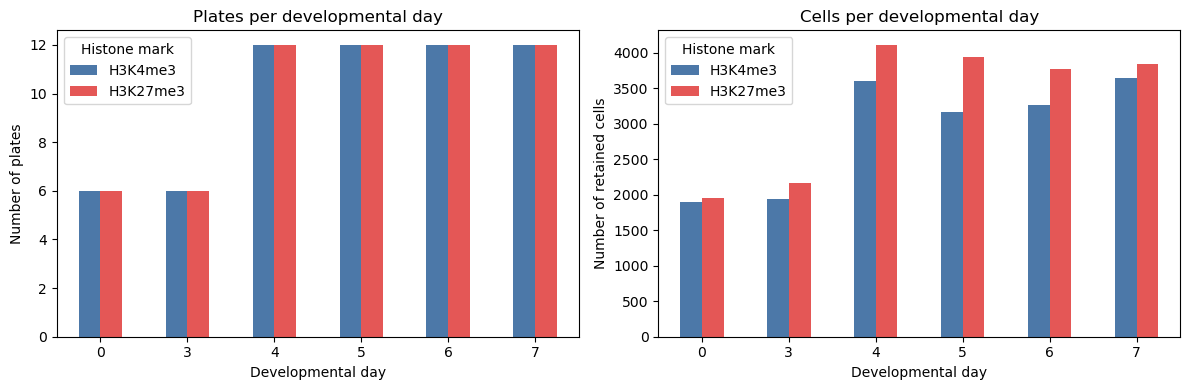

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plates_by_day.plot(
    kind="bar",
    ax=axes[0],
    color=["#4C78A8", "#E45756"],
)
axes[0].set_title("Plates per developmental day")
axes[0].set_xlabel("Developmental day")
axes[0].set_ylabel("Number of plates")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Histone mark")

cells_by_day.plot(
    kind="bar",
    ax=axes[1],
    color=["#4C78A8", "#E45756"],
)
axes[1].set_title("Cells per developmental day")
axes[1].set_xlabel("Developmental day")
axes[1].set_ylabel("Number of retained cells")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Histone mark")

plt.tight_layout()
plt.show()

### Experimental replicate composition

An experimental replicate is an independently performed experimental repetition or collection. Multiple plates can belong to the same replicate. Replicates help determine whether a biological pattern is reproducible across independent experiments.

The precise laboratory definition of `rep2`, `rep3` and `rep4` should be confirmed with the data producer if it must be described in detail. For split design, the important question is how these replicate labels are distributed across developmental days.

In [9]:
plates_by_day_and_rep = pd.crosstab(
    [
        plate_table["mark"],
        plate_table["day"],
    ],
    plate_table["rep"],
).reindex(
    columns=["rep2", "rep3", "rep4"],
    fill_value=0,
)

cells_by_day_and_rep = pd.pivot_table(
    plate_table,
    index=["mark", "day"],
    columns="rep",
    values="n_cells",
    aggfunc="sum",
    fill_value=0,
    observed=True,
).reindex(
    columns=["rep2", "rep3", "rep4"],
    fill_value=0,
)

print("Number of plates by mark, day and replicate:")
display(plates_by_day_and_rep)

print("Number of cells by mark, day and replicate:")
display(cells_by_day_and_rep)

Number of plates by mark, day and replicate:


rep           rep2  rep3  rep4
mark     day                  
H3K4me3  0       0     0     6
         3       0     6     0
         4       0    12     0
         5       6     6     0
         6       6     6     0
         7       6     6     0
H3K27me3 0       0     0     6
         3       0     6     0
         4       0     6     6
         5       6     2     4
         6       6     6     0
         7       6     6     0

Number of cells by mark, day and replicate:


rep           rep2  rep3  rep4
mark     day                  
H3K4me3  0       0     0  1892
         3       0  1937     0
         4       0  3603     0
         5    1754  1409     0
         6    1659  1606     0
         7    1855  1783     0
H3K27me3 0       0     0  1953
         3       0  2167     0
         4       0  2152  1955
         5    1935   689  1319
         6    1958  1806     0
         7    1921  1912     0

### Interpretation

Each histone-mark task contains:

- 6 plates at day 0;
- 6 plates at day 3;
- 12 plates at each of days 4, 5, 6 and 7.

This permits every developmental day to be represented in train, validation and test.

However, experimental replicates are not independently represented at every day:

- day 0 contains only `rep4`;
- day 3 contains only `rep3`;
- H3K4me3 day 4 contains only `rep3`;
- later days contain different combinations of `rep2`, `rep3` and `rep4`.

Consequently, holding out an entire replicate would also remove or disproportionately affect particular developmental days. Replicate and developmental-stage effects would then be confounded.

The primary split will therefore:

1. use the individual plate (`sample`) as the indivisible grouping unit;
2. require every developmental day in every partition;
3. balance replicate labels where the experimental design permits it;
4. not require complete experimental replicates to remain in one partition.

## 5. Technical composition of the plates

Sequencing runs and broad experimental batches can introduce technical variation. Their distributions should therefore be examined before constructing the split.

These variables are used as balancing and diagnostic variables. They are not automatically suitable as hard grouping variables because they may be associated with particular developmental days or experimental replicates.

In [10]:
exp_batch_order = ["2022", "2023"]
seqrun_order = ["OUDxxxx", "OUD8207", "OUD8208", "OUD8209"]

plates_by_exp_batch = pd.crosstab(
    [
        plate_table["mark"],
        plate_table["day"],
    ],
    plate_table["exp_batch"].astype(str),
).reindex(
    columns=exp_batch_order,
    fill_value=0,
)

plates_by_seqrun = pd.crosstab(
    [
        plate_table["mark"],
        plate_table["day"],
    ],
    plate_table["seqrun"].astype(str),
).reindex(
    columns=seqrun_order,
    fill_value=0,
)

print("Number of plates by mark, day and experimental batch:")
display(plates_by_exp_batch)

print("Number of plates by mark, day and sequencing run:")
display(plates_by_seqrun)

Number of plates by mark, day and experimental batch:


exp_batch     2022  2023
mark     day            
H3K4me3  0       6     0
         3       6     0
         4       6     6
         5       6     6
         6       6     6
         7       6     6
H3K27me3 0       6     0
         3       6     0
         4      12     0
         5      12     0
         6       6     6
         7       6     6

Number of plates by mark, day and sequencing run:


seqrun        OUDxxxx  OUD8207  OUD8208  OUD8209
mark     day                                    
H3K4me3  0          6        0        0        0
         3          6        0        0        0
         4          6        0        6        0
         5          6        0        6        0
         6          6        0        0        6
         7          6        6        0        0
H3K27me3 0          6        0        0        0
         3          6        0        0        0
         4         12        0        0        0
         5         12        0        0        0
         6          6        6        0        0
         7          6        6        0        0

In [11]:
print("Total plates by mark and experimental batch:")
display(
    pd.crosstab(
        plate_table["mark"],
        plate_table["exp_batch"].astype(str),
    ).reindex(
        columns=exp_batch_order,
        fill_value=0,
    )
)

print("Total plates by mark and sequencing run:")
display(
    pd.crosstab(
        plate_table["mark"],
        plate_table["seqrun"].astype(str),
    ).reindex(
        columns=seqrun_order,
        fill_value=0,
    )
)

Total plates by mark and experimental batch:


exp_batch,2022,2023
mark,,
H3K4me3,36,24
H3K27me3,48,12


Total plates by mark and sequencing run:


seqrun,OUDxxxx,OUD8207,OUD8208,OUD8209
mark,,,,
H3K4me3,36,6,12,6
H3K27me3,48,12,0,0


In [12]:
batch_run_relationship = pd.crosstab(
    [
        plate_table["mark"],
        plate_table["exp_batch"].astype(str),
    ],
    plate_table["seqrun"].astype(str),
).reindex(
    columns=seqrun_order,
    fill_value=0,
)

print("Relationship between experimental batch and sequencing run:")
display(batch_run_relationship)

runs_per_exp_batch = (
    plate_table.groupby(
        ["mark", "exp_batch"],
        observed=True,
    )["seqrun"]
    .nunique()
)

exp_batches_per_run = (
    plate_table.groupby(
        ["mark", "seqrun"],
        observed=True,
    )["exp_batch"]
    .nunique()
)

print(
    "Maximum experimental batches associated with one sequencing run:",
    exp_batches_per_run.max(),
)
print(
    "Maximum sequencing runs associated with one experimental batch:",
    runs_per_exp_batch.max(),
)

Relationship between experimental batch and sequencing run:


seqrun              OUDxxxx  OUD8207  OUD8208  OUD8209
mark     exp_batch                                    
H3K4me3  2022            36        0        0        0
         2023             0        6       12        6
H3K27me3 2022            48        0        0        0
         2023             0       12        0        0

Maximum experimental batches associated with one sequencing run: 1
Maximum sequencing runs associated with one experimental batch: 3


### Technical-batch interpretation

The broad experimental-batch variable and sequencing-run variable contain overlapping information. The 2022 plates were assigned to `OUDxxxx`, while the 2023 plates were assigned to one of the specifically numbered sequencing runs.

The split should therefore represent the available sequencing runs across partitions where possible. Experimental-batch balance should still be reported, but it should not receive an additional equal optimization weight if sequencing run is already being optimized, because that would partly count the same technical structure twice.

Technical runs cannot be treated as completely independent of developmental day because particular runs occur only at particular days. They are therefore balancing variables rather than the main grouping unit.

## 6. Split specification

The two histone marks are treated as separate prediction tasks. Each task contains 60 complete plates and will be divided into:

| Partition | Plates | Percentage |
|---|---:|---:|
| Train | 42 | 70% |
| Validation | 9 | 15% |
| Test | 9 | 15% |

### Hard requirements

A valid candidate split must satisfy all of the following:

1. Every plate (`sample`) is assigned to exactly one partition.
2. All cells belonging to a plate receive the same assignment.
3. Each histone mark is split independently.
4. Each task contains exactly 42 train, 9 validation and 9 test plates.
5. Every developmental day occurs in every partition.
6. A 6-plate day uses a 4/1/1 allocation.
7. A 12-plate day uses one of:
   - 8/2/2;
   - 9/1/2;
   - 9/2/1.
8. No 12-plate day contributes three validation or three test plates.
9. Every available replicate label occurs in every partition.
10. Every available sequencing run occurs in every partition.

### Optimization preferences

Among valid candidates, prefer assignments that:

1. closely match the intended cell proportions within each developmental day;
2. closely match 70/15/15 in overall cell counts;
3. distribute day-and-replicate combinations reasonably;
4. balance replicate and sequencing-run composition.

`exp_batch` is reported as a diagnostic but is not independently optimized because it is already encoded at a broader level by `seqrun`.

A fixed random seed makes the search reproducible.

In [13]:
SPLIT_NAMES = np.array(["train", "validation", "test"])
TARGET_PROPORTIONS = np.array([0.70, 0.15, 0.15])
TARGET_PLATE_COUNTS = np.array([42, 9, 9])

SEED = 42
N_ITERATIONS = 150_000

EXPECTED_PLATES_PER_DAY = {
    0: 6,
    3: 6,
    4: 12,
    5: 12,
    6: 12,
    7: 12,
}

ALLOWED_DAY_ALLOCATIONS = {
    6: {
        (4, 1, 1),
    },
    12: {
        (8, 2, 2),
        (9, 1, 2),
        (9, 2, 1),
    },
}

for mark in mark_order:
    mark_plates = plate_table.loc[plate_table["mark"] == mark]

    assert len(mark_plates) == 60

    observed_per_day = (
        mark_plates["day"]
        .value_counts()
        .sort_index()
        .to_dict()
    )

    assert observed_per_day == EXPECTED_PLATES_PER_DAY

print("Split design assumptions passed.")
print("Plates per mark: 60")
print("Required allocation per mark: 42 train / 9 validation / 9 test")
print()
print("Expected plates per developmental day:")
display(
    pd.Series(
        EXPECTED_PLATES_PER_DAY,
        name="n_plates",
    ).rename_axis("day").to_frame()
)

Split design assumptions passed.
Plates per mark: 60
Required allocation per mark: 42 train / 9 validation / 9 test

Expected plates per developmental day:


,n_plates
day,
0,6
3,6
4,12
5,12
6,12
7,12


### Candidate generation

Each candidate is generated within developmental days rather than by randomly dividing all 60 plates at once.

For days containing 6 plates, the allocation is always 4/1/1.

Across the four days containing 12 plates:

- two days receive an 8/2/2 allocation;
- one day receives a 9/1/2 allocation;
- one day receives a 9/2/1 allocation.

Together with days 0 and 3, this always produces exactly 42/9/9 plates while keeping validation and test representation balanced across developmental days.

In [14]:
def generate_candidate_labels(frame, rng):
    """Generate one candidate satisfying plate-count and day constraints."""

    labels = np.full(len(frame), fill_value=-1, dtype=np.int8)

    six_plate_days = [
        day for day, count in EXPECTED_PLATES_PER_DAY.items()
        if count == 6
    ]
    twelve_plate_days = [
        day for day, count in EXPECTED_PLATES_PER_DAY.items()
        if count == 12
    ]

    # Exactly two 12-plate days need 9 training plates.
    nine_train_days = set(
        rng.choice(
            twelve_plate_days,
            size=2,
            replace=False,
        ).tolist()
    )

    # Of those two days, one uses 9/1/2 and one uses 9/2/1.
    validation_light_day = int(
        rng.choice(sorted(nine_train_days))
    )

    day_values = frame["day"].to_numpy()

    for day in six_plate_days + twelve_plate_days:
        day_indices = np.flatnonzero(day_values == day)
        shuffled_indices = rng.permutation(day_indices)

        if len(day_indices) == 6:
            allocation = (4, 1, 1)

        elif day not in nine_train_days:
            allocation = (8, 2, 2)

        elif day == validation_light_day:
            allocation = (9, 1, 2)

        else:
            allocation = (9, 2, 1)

        train_end = allocation[0]
        validation_end = allocation[0] + allocation[1]

        labels[shuffled_indices[:train_end]] = 0
        labels[
            shuffled_indices[train_end:validation_end]
        ] = 1
        labels[shuffled_indices[validation_end:]] = 2

    assert np.all(labels >= 0)
    assert np.array_equal(
        np.bincount(labels, minlength=3),
        TARGET_PLATE_COUNTS,
    )

    return labels

In [15]:
test_frame = (
    plate_table.loc[plate_table["mark"] == "H3K4me3"]
    .copy()
    .reset_index(drop=True)
)

test_rng = np.random.default_rng(SEED)
test_labels = generate_candidate_labels(test_frame, test_rng)

test_candidate = test_frame.copy()
test_candidate["split"] = pd.Categorical(
    SPLIT_NAMES[test_labels],
    categories=SPLIT_NAMES,
    ordered=True,
)

test_plate_counts = pd.crosstab(
    test_candidate["day"],
    test_candidate["split"],
).reindex(
    index=day_order,
    columns=SPLIT_NAMES,
    fill_value=0,
)

for day, row in test_plate_counts.iterrows():
    allocation = tuple(row.astype(int))
    n_day_plates = EXPECTED_PLATES_PER_DAY[day]

    assert allocation in ALLOWED_DAY_ALLOCATIONS[n_day_plates]

assert tuple(test_plate_counts.sum()) == tuple(TARGET_PLATE_COUNTS)

print("Generated candidate passed structural checks.")
print()
print("Plates by developmental day and split:")
display(test_plate_counts)

print("Overall plate counts:")
display(
    test_candidate["split"]
    .value_counts(sort=False)
    .rename("n_plates")
    .to_frame()
)

Generated candidate passed structural checks.

Plates by developmental day and split:


split,train,validation,test
day,,,
0,4,1,1
3,4,1,1
4,9,1,2
5,8,2,2
6,8,2,2
7,9,2,1


Overall plate counts:


,n_plates
split,
train,42
validation,9
test,9


### Required-category coverage

The day-aware generator guarantees structural balance but does not automatically guarantee that every replicate and sequencing run occurs in all three partitions.

Candidates that omit an available replicate or sequencing run from any partition are rejected. Indicator matrices are prepared once so that this check can be performed efficiently during the randomized search.

In [16]:
def category_indicator_matrix(frame, column):
    """Return category names and a category-by-plate indicator matrix."""

    values = frame[column].astype(str).to_numpy()
    categories = np.sort(np.unique(values))

    matrix = np.vstack([
        values == category
        for category in categories
    ]).astype(np.int8)

    return categories, matrix


def category_counts_by_split(matrix, labels):
    """Count each category in train, validation and test."""

    return np.column_stack([
        matrix[:, labels == split_index].sum(axis=1)
        for split_index in range(len(SPLIT_NAMES))
    ])


def coverage_table(frame, labels, column):
    """Create a readable category-by-split count table."""

    categories, matrix = category_indicator_matrix(frame, column)
    counts = category_counts_by_split(matrix, labels)

    return pd.DataFrame(
        counts,
        index=pd.Index(categories, name=column),
        columns=pd.Index(SPLIT_NAMES, name="split"),
    )


def has_complete_category_coverage(frame, labels, columns):
    """Return True when every category occurs in every partition."""

    for column in columns:
        _, matrix = category_indicator_matrix(frame, column)
        counts = category_counts_by_split(matrix, labels)

        if np.any(counts == 0):
            return False

    return True

In [17]:
required_coverage_columns = ["rep", "seqrun"]

print("Replicate coverage in the test candidate:")
display(
    coverage_table(
        test_frame,
        test_labels,
        "rep",
    )
)

print("Sequencing-run coverage in the test candidate:")
display(
    coverage_table(
        test_frame,
        test_labels,
        "seqrun",
    )
)

test_candidate_has_coverage = has_complete_category_coverage(
    test_frame,
    test_labels,
    required_coverage_columns,
)

print(
    "Candidate passes all required category-coverage checks:",
    test_candidate_has_coverage,
)

Replicate coverage in the test candidate:


split,train,validation,test
rep,,,
rep2,12,5,1
rep3,26,3,7
rep4,4,1,1


Sequencing-run coverage in the test candidate:


split,train,validation,test
seqrun,,,
OUD8207,5,0,1
OUD8208,10,1,1
OUD8209,3,1,2
OUDxxxx,24,7,5


Candidate passes all required category-coverage checks: False


### Candidate scoring

Hard constraints determine whether a candidate is valid. A numerical score is then used only to compare valid candidates.

All error components are expressed as root-mean-square deviations in percentage points. Lower values indicate better balance.

- `within_day_cell_rmse`: difference between the cell proportions and plate proportions within each developmental day;
- `overall_cell_rmse`: difference between overall cell proportions and 70/15/15;
- `day_rep_rmse`: balance of each available day-and-replicate combination;
- `rep_rmse`: overall replicate balance;
- `seqrun_rmse`: overall sequencing-run balance.

Cell-balance components receive the greatest importance. Metadata components have lower weights because structural and coverage requirements already prevent severe imbalance.

The weights are explicit so that their influence can be inspected and adjusted during sensitivity analysis.

In [18]:
SCORE_WEIGHTS = {
    "within_day_cell_rmse": 1.0,
    "overall_cell_rmse": 1.0,
    "day_rep_rmse": 0.25,
    "rep_rmse": 0.10,
    "seqrun_rmse": 0.10,
}


def categorical_balance_rmse(frame, labels, column):
    """RMSE from 70/15/15 for every category of a metadata field."""

    _, matrix = category_indicator_matrix(frame, column)
    counts = category_counts_by_split(matrix, labels)
    totals = matrix.sum(axis=1, keepdims=True)

    observed_proportions = counts / totals

    return float(
        100 * np.sqrt(
            np.mean(
                (
                    observed_proportions
                    - TARGET_PROPORTIONS
                ) ** 2
            )
        )
    )


def score_candidate(frame, labels):
    """Calculate interpretable balance scores for one candidate."""

    cell_counts = frame["n_cells"].to_numpy(dtype=float)

    overall_cells_by_split = np.array([
        cell_counts[labels == split_index].sum()
        for split_index in range(len(SPLIT_NAMES))
    ])

    overall_cell_proportions = (
        overall_cells_by_split
        / overall_cells_by_split.sum()
    )

    overall_cell_rmse = float(
        100 * np.sqrt(
            np.mean(
                (
                    overall_cell_proportions
                    - TARGET_PROPORTIONS
                ) ** 2
            )
        )
    )

    within_day_differences = []

    for day in day_order:
        day_mask = frame["day"].to_numpy() == day
        day_labels = labels[day_mask]
        day_cells = cell_counts[day_mask]

        day_plate_counts = np.bincount(
            day_labels,
            minlength=len(SPLIT_NAMES),
        )
        day_plate_proportions = (
            day_plate_counts
            / day_plate_counts.sum()
        )

        day_cell_counts = np.array([
            day_cells[day_labels == split_index].sum()
            for split_index in range(len(SPLIT_NAMES))
        ])
        day_cell_proportions = (
            day_cell_counts
            / day_cell_counts.sum()
        )

        within_day_differences.extend(
            day_cell_proportions
            - day_plate_proportions
        )

    within_day_cell_rmse = float(
        100 * np.sqrt(
            np.mean(
                np.square(within_day_differences)
            )
        )
    )

    components = {
        "within_day_cell_rmse": within_day_cell_rmse,
        "overall_cell_rmse": overall_cell_rmse,
        "day_rep_rmse": categorical_balance_rmse(
            frame,
            labels,
            "day_rep",
        ),
        "rep_rmse": categorical_balance_rmse(
            frame,
            labels,
            "rep",
        ),
        "seqrun_rmse": categorical_balance_rmse(
            frame,
            labels,
            "seqrun",
        ),
    }

    total_score = sum(
        SCORE_WEIGHTS[name] * value
        for name, value in components.items()
    )

    return {
        "total_score": total_score,
        **components,
    }

In [19]:
test_scores = score_candidate(
    test_frame,
    test_labels,
)

display(
    pd.Series(
        test_scores,
        name="score",
    ).to_frame()
)

,score
total_score,6.101885
within_day_cell_rmse,1.348263
overall_cell_rmse,0.239963
day_rep_rmse,11.175738
rep_rmse,6.230594
seqrun_rmse,10.966654


In [20]:
def prepare_search_data(frame):
    """Precompute arrays used repeatedly during candidate evaluation."""

    return {
        "cell_counts": frame["n_cells"].to_numpy(dtype=float),
        "day_masks": {
            day: frame["day"].to_numpy() == day
            for day in day_order
        },
        "category_matrices": {
            column: category_indicator_matrix(frame, column)[1]
            for column in [
                "day_rep",
                "rep",
                "seqrun",
            ]
        },
    }


def categorical_rmse_from_matrix(matrix, labels):
    counts = category_counts_by_split(matrix, labels)
    totals = matrix.sum(axis=1, keepdims=True)
    observed_proportions = counts / totals

    return float(
        100 * np.sqrt(
            np.mean(
                (
                    observed_proportions
                    - TARGET_PROPORTIONS
                ) ** 2
            )
        )
    )


def score_candidate_precomputed(labels, prepared):
    """Calculate the same scores using precomputed arrays."""

    cell_counts = prepared["cell_counts"]

    overall_cells_by_split = np.array([
        cell_counts[labels == split_index].sum()
        for split_index in range(len(SPLIT_NAMES))
    ])

    overall_cell_proportions = (
        overall_cells_by_split
        / overall_cells_by_split.sum()
    )

    overall_cell_rmse = float(
        100 * np.sqrt(
            np.mean(
                (
                    overall_cell_proportions
                    - TARGET_PROPORTIONS
                ) ** 2
            )
        )
    )

    within_day_differences = []

    for day in day_order:
        day_mask = prepared["day_masks"][day]
        day_labels = labels[day_mask]
        day_cells = cell_counts[day_mask]

        day_plate_counts = np.bincount(
            day_labels,
            minlength=len(SPLIT_NAMES),
        )
        day_plate_proportions = (
            day_plate_counts
            / day_plate_counts.sum()
        )

        day_cell_counts = np.array([
            day_cells[day_labels == split_index].sum()
            for split_index in range(len(SPLIT_NAMES))
        ])
        day_cell_proportions = (
            day_cell_counts
            / day_cell_counts.sum()
        )

        within_day_differences.extend(
            day_cell_proportions
            - day_plate_proportions
        )

    components = {
        "within_day_cell_rmse": float(
            100 * np.sqrt(
                np.mean(
                    np.square(within_day_differences)
                )
            )
        ),
        "overall_cell_rmse": overall_cell_rmse,
        "day_rep_rmse": categorical_rmse_from_matrix(
            prepared["category_matrices"]["day_rep"],
            labels,
        ),
        "rep_rmse": categorical_rmse_from_matrix(
            prepared["category_matrices"]["rep"],
            labels,
        ),
        "seqrun_rmse": categorical_rmse_from_matrix(
            prepared["category_matrices"]["seqrun"],
            labels,
        ),
    }

    total_score = sum(
        SCORE_WEIGHTS[name] * value
        for name, value in components.items()
    )

    return {
        "total_score": total_score,
        **components,
    }

In [21]:
test_prepared = prepare_search_data(test_frame)

fast_test_scores = score_candidate_precomputed(
    test_labels,
    test_prepared,
)

for score_name in test_scores:
    np.testing.assert_allclose(
        fast_test_scores[score_name],
        test_scores[score_name],
    )

print("Precomputed scoring matches the reference implementation.")

Precomputed scoring matches the reference implementation.


In [22]:
def search_best_split(frame, seed, n_iterations):
    """Generate, validate and score candidate plate assignments."""

    rng = np.random.default_rng(seed)
    prepared = prepare_search_data(frame)

    coverage_matrices = [
        prepared["category_matrices"]["rep"],
        prepared["category_matrices"]["seqrun"],
    ]

    best_labels = None
    best_scores = None
    best_total_score = np.inf
    valid_candidates = 0

    for _ in range(n_iterations):
        labels = generate_candidate_labels(frame, rng)

        has_required_coverage = all(
            np.all(
                category_counts_by_split(
                    matrix,
                    labels,
                ) > 0
            )
            for matrix in coverage_matrices
        )

        if not has_required_coverage:
            continue

        valid_candidates += 1

        scores = score_candidate_precomputed(
            labels,
            prepared,
        )

        if scores["total_score"] < best_total_score:
            best_total_score = scores["total_score"]
            best_labels = labels.copy()
            best_scores = scores.copy()

    if best_labels is None:
        raise RuntimeError(
            "No valid candidate was found."
        )

    result = frame.copy()
    result["split"] = pd.Categorical(
        SPLIT_NAMES[best_labels],
        categories=SPLIT_NAMES,
        ordered=True,
    )

    return result, best_scores, valid_candidates

In [23]:
best_assignments = {}
search_results = []

for mark_number, mark in enumerate(mark_order):
    frame = (
        plate_table.loc[plate_table["mark"] == mark]
        .copy()
        .reset_index(drop=True)
    )

    assignment, scores, valid_candidates = search_best_split(
        frame=frame,
        seed=SEED + mark_number,
        n_iterations=N_ITERATIONS,
    )

    best_assignments[mark] = assignment

    search_results.append({
        "mark": mark,
        "iterations": N_ITERATIONS,
        "valid_candidates": valid_candidates,
        **scores,
    })

    print(f"Completed search for {mark}.")
    print(f"Valid candidates: {valid_candidates:,}")
    print(f"Best total score: {scores['total_score']:.6f}")
    print()

search_summary = pd.DataFrame(search_results).set_index("mark")
display(search_summary)

Completed search for H3K4me3.
Valid candidates: 24,749
Best total score: 2.293528

Completed search for H3K27me3.
Valid candidates: 120,148
Best total score: 3.029385



,iterations,valid_candidates,total_score,within_day_cell_rmse,overall_cell_rmse,day_rep_rmse,rep_rmse,seqrun_rmse
mark,,,,,,,,
H3K4me3,150000,24749,2.293528,0.640258,0.040831,4.692170,2.206736,2.187224
H3K27me3,150000,120148,3.029385,0.512470,0.027417,8.236815,2.584984,1.717961


## 7. Evaluation of the selected candidates

The best valid candidate for each histone mark is inspected before any assignment is exported. The first checks concern overall cell proportions and developmental-day balance.

In [24]:
def display_overall_and_day_balance(assignment):
    """Display overall and developmental-day balance."""

    overall_summary = (
        assignment.groupby("split", observed=False)
        .agg(
            n_plates=("sample", "size"),
            n_cells=("n_cells", "sum"),
        )
    )

    overall_summary["plate_percent"] = (
        100
        * overall_summary["n_plates"]
        / overall_summary["n_plates"].sum()
    )

    overall_summary["cell_percent"] = (
        100
        * overall_summary["n_cells"]
        / overall_summary["n_cells"].sum()
    )

    day_plate_counts = pd.crosstab(
        assignment["day"],
        assignment["split"],
    ).reindex(
        index=day_order,
        columns=SPLIT_NAMES,
        fill_value=0,
    )

    day_cell_counts = pd.pivot_table(
        assignment,
        index="day",
        columns="split",
        values="n_cells",
        aggfunc="sum",
        fill_value=0,
        observed=True,
    ).reindex(
        index=day_order,
        columns=SPLIT_NAMES,
        fill_value=0,
    )

    day_cell_percentages = (
        day_cell_counts
        .div(day_cell_counts.sum(axis=1), axis=0)
        * 100
    )

    print("Overall split:")
    display(
        overall_summary.style.format({
            "plate_percent": "{:.3f}",
            "cell_percent": "{:.3f}",
        })
    )

    print("Plates by developmental day:")
    display(day_plate_counts)

    print("Cells by developmental day:")
    display(day_cell_counts)

    print("Cell percentages within each developmental day:")
    display(
        day_cell_percentages.style.format("{:.3f}")
    )

In [25]:
for mark in mark_order:
    print("=" * 70)
    print(mark)
    print("=" * 70)

    display_overall_and_day_balance(
        best_assignments[mark]
    )

H3K4me3
Overall split:


,n_plates,n_cells,plate_percent,cell_percent
split,,,,
train,42,12251,70.000,70.014
validation,9,2632,15.000,15.042
test,9,2615,15.000,14.945


Plates by developmental day:


split,train,validation,test
day,,,
0,4,1,1
3,4,1,1
4,9,1,2
5,9,2,1
6,8,2,2
7,8,2,2


Cells by developmental day:


...

split,train,validation,test
day,,,
0,4,1,1
3,4,1,1
4,9,1,2
5,9,2,1
6,8,2,2
7,8,2,2


Cells by developmental day:


split,train,validation,test
day,,,
0,1285,330,338
3,1447,362,358
4,3073,335,699
5,2975,632,336
6,2510,670,584
7,2554,635,644


Cell percentages within each developmental day:


split,train,validation,test
day,,,
0,65.796,16.897,17.307
3,66.774,16.705,16.521
4,74.823,8.157,17.020
5,75.450,16.028,8.521
6,66.684,17.800,15.515
7,66.632,16.567,16.801


### Replicate and technical-batch balance

The following tables verify required coverage and document the remaining differences between partitions. Complete equality is not expected because replicate and sequencing-run labels are associated with particular developmental days.

In [26]:
def display_metadata_balance(assignment):
    labels = assignment["split"].cat.codes.to_numpy()

    for column, title in [
        ("rep", "Experimental replicates"),
        ("seqrun", "Sequencing runs"),
        ("exp_batch", "Experimental batches"),
    ]:
        print(title + ":")
        display(
            coverage_table(
                assignment,
                labels,
                column,
            )
        )

    print("Day-and-replicate combinations:")
    display(
        pd.crosstab(
            [
                assignment["day"],
                assignment["rep"],
            ],
            assignment["split"],
        ).reindex(
            columns=SPLIT_NAMES,
            fill_value=0,
        )
    )


for mark in mark_order:
    print("=" * 70)
    print(mark)
    print("=" * 70)

    display_metadata_balance(
        best_assignments[mark]
    )

H3K4me3
Experimental replicates:


split,train,validation,test
rep,,,
rep2,13,3,2
rep3,25,5,6
rep4,4,1,1


Sequencing runs:


split,train,validation,test
seqrun,,,
OUD8207,4,1,1
OUD8208,8,2,2
OUD8209,4,1,1
OUDxxxx,26,5,5


Experimental batches:


...

split,train,validation,test
seqrun,,,
OUD8207,8,2,2
OUDxxxx,34,7,7


Experimental batches:


split,train,validation,test
exp_batch,,,
2022,34,7,7
2023,8,2,2


Day-and-replicate combinations:


split     train  validation  test
day rep                          
0   rep4      4           1     1
3   rep3      4           1     1
4   rep3      5           0     1
    rep4      4           1     1
5   rep2      4           1     1
    rep3      2           0     0
    rep4      3           1     0
6   rep2      4           1     1
    rep3      4           1     1
7   rep2      4           1     1
    rep3      4           1     1

### Structural and leakage validation

The final checks verify that:

- all 120 plates are assigned;
- every plate is assigned exactly once;
- all 37,265 cells receive an assignment;
- no plate occurs in multiple partitions;
- the histone-mark label remains consistent;
- every required replicate and sequencing run is represented.

In [27]:
combined_assignment = pd.concat(
    [
        best_assignments[mark]
        for mark in mark_order
    ],
    ignore_index=True,
)

assert len(combined_assignment) == 120
assert combined_assignment["sample"].is_unique

split_mapping = (
    combined_assignment
    .set_index("sample")["split"]
    .map(str)
)

mark_mapping = (
    combined_assignment
    .set_index("sample")["mark"]
    .astype(str)
)

cell_assignments = pd.DataFrame({
    "sample": obs["sample"].astype(str),
    "original_mark": obs["mark"].astype(str),
})

cell_assignments["split"] = (
    cell_assignments["sample"]
    .map(split_mapping)
)

cell_assignments["assigned_mark"] = (
    cell_assignments["sample"]
    .map(mark_mapping)
)

unassigned_cells = int(
    cell_assignments["split"].isna().sum()
)

mark_mismatches = int(
    (
        cell_assignments["original_mark"]
        != cell_assignments["assigned_mark"]
    ).sum()
)

samples_in_multiple_splits = int(
    cell_assignments
    .groupby("sample", observed=True)["split"]
    .nunique()
    .gt(1)
    .sum()
)

for mark in mark_order:
    assignment = best_assignments[mark]
    labels = assignment["split"].cat.codes.to_numpy()

    assert tuple(
        np.bincount(labels, minlength=3)
    ) == tuple(TARGET_PLATE_COUNTS)

    assert has_complete_category_coverage(
        assignment,
        labels,
        required_coverage_columns,
    )

    day_counts = pd.crosstab(
        assignment["day"],
        assignment["split"],
    ).reindex(
        index=day_order,
        columns=SPLIT_NAMES,
        fill_value=0,
    )

    for day, row in day_counts.iterrows():
        allocation = tuple(row.astype(int))
        n_day_plates = EXPECTED_PLATES_PER_DAY[day]

        assert (
            allocation
            in ALLOWED_DAY_ALLOCATIONS[n_day_plates]
        )

assert unassigned_cells == 0
assert mark_mismatches == 0
assert samples_in_multiple_splits == 0

print("FINAL VALIDATION PASSED")
print("Assigned plates:", len(combined_assignment))
print("Assigned cells:", len(cell_assignments))
print("Unassigned cells:", unassigned_cells)
print("Histone-mark mismatches:", mark_mismatches)
print(
    "Samples appearing in multiple splits:",
    samples_in_multiple_splits,
)

FINAL VALIDATION PASSED
Assigned plates: 120
Assigned cells: 37265
Unassigned cells: 0
Histone-mark mismatches: 0
Samples appearing in multiple splits: 0


## Export deterministic plate split assignments

The split search above is the source of truth for the train/validation/test
assignment. This section exports the selected per-plate assignments for
downstream benchmark-preparation notebooks.

The exported CSV files are generated artifacts. They should not be edited
manually; rerunning this notebook recreates them from the fixed split-design
procedure above.

In [29]:
from pathlib import Path

repo_root = Path("..").resolve()

assert (repo_root / "src").is_dir()
assert (repo_root / "notebooks").is_dir()

split_output_dir = repo_root / "outputs" / "tchic" / "splits"
split_output_dir.mkdir(parents=True, exist_ok=True)

export_names = {
    "H3K4me3": "h3k4me3_plate_split.csv",
    "H3K27me3": "h3k27me3_plate_split.csv",
}

exported_assignments = {}

for mark, filename in export_names.items():
    assignment = best_assignments[mark].copy()

    assignment["sample"] = assignment["sample"].astype(str)
    assignment["split"] = assignment["split"].astype(str)

    assignment = (
        assignment
        .sort_values("sample", kind="stable")
        .reset_index(drop=True)
    )

    assert len(assignment) == 60
    assert assignment["sample"].is_unique

    split_counts = assignment["split"].value_counts().to_dict()
    assert split_counts == {
        "train": 42,
        "validation": 9,
        "test": 9,
    }

    output_path = split_output_dir / filename
    assignment.to_csv(output_path, index=False)

    exported_assignments[mark] = assignment

    print(f"{mark}: {output_path}")
    print(split_counts)

combined_plate_splits = (
    pd.concat(
        [exported_assignments["H3K4me3"],
         exported_assignments["H3K27me3"]],
        ignore_index=True,
    )
    .sort_values(["mark", "sample"], kind="stable")
    .reset_index(drop=True)
)

assert len(combined_plate_splits) == 120
assert combined_plate_splits["sample"].is_unique

combined_path = split_output_dir / "all_plate_splits.csv"
combined_plate_splits.to_csv(combined_path, index=False)

search_summary_path = split_output_dir / "split_search_summary.csv"
search_summary.to_csv(search_summary_path)

print("\nCombined:", combined_path)
print("Search summary:", search_summary_path)
print("Total plates:", len(combined_plate_splits))

H3K4me3: /home/michiel/thesis/benchmark/task_predict_modality_upstream_validation/outputs/tchic/splits/h3k4me3_plate_split.csv
{'train': 42, 'test': 9, 'validation': 9}
H3K27me3: /home/michiel/thesis/benchmark/task_predict_modality_upstream_validation/outputs/tchic/splits/h3k27me3_plate_split.csv
{'train': 42, 'validation': 9, 'test': 9}

Combined: /home/michiel/thesis/benchmark/task_predict_modality_upstream_validation/outputs/tchic/splits/all_plate_splits.csv
Search summary: /home/michiel/thesis/benchmark/task_predict_modality_upstream_validation/outputs/tchic/splits/split_search_summary.csv
Total plates: 120
